# 03 – Data Cleaning

## Purpose
This notebook applies corrective transformations to the FinLora transaction dataset,
based on the data quality issues identified in `02_data_profiling.ipynb`.

For each issue, this notebook documents:
- The decision made
- The justification for that decision
- The code implementing it

This notebook does not introduce new diagnostic analysis — that was completed in
Data Profiling. Where a cleaning step requires a judgment call (e.g. how to impute
a missing value), the reasoning is stated explicitly rather than applied silently.

## Cleaning Order
1. Remove exact duplicate records
2. Resolve disguised missing values (placeholder numerics, literal "NaN" text, malformed timestamps)
3. Fix data type issues (amount_src, timestamp)
4. Apply missing-value treatment (now using the corrected missingness picture)
5. Standardize categorical values
6. Note: class imbalance and data leakage findings are carried forward to
   Feature Engineering / Model Development, not resolved here

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Dataset"
    / "raw"
    / "FinLora_Customer_Transaction_Dataset.csv"
)

df = pd.read_csv(DATA_PATH)

In [4]:
df

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,...,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,...,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,...,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,...,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0


In [5]:
# ------------------------------------------------------------------
# Before removing any duplicate rows: verify timestamps are IDENTICAL
# (not just very close) within each duplicate pair
# ------------------------------------------------------------------
# This is a security-relevant check, not just a data quality one.
# If duplicate pairs share the exact same timestamp down to the
# microsecond, that is strong evidence of a single event being
# logged twice (safe to deduplicate). If timestamps differ even
# slightly, that could indicate two SEPARATE real transactions
# that happen to share a transaction_id - which would be a
# genuinely different, more serious issue requiring investigation
# rather than simple deduplication.

duplicate_id_counts = df["transaction_id"].value_counts()
duplicated_ids = duplicate_id_counts[duplicate_id_counts > 1].index

# For every duplicated transaction_id, check if the timestamps within
# that group are identical or different
timestamp_check = df[df["transaction_id"].isin(duplicated_ids)].groupby("transaction_id")["timestamp"].nunique()

identical_timestamp_pairs = (timestamp_check == 1).sum()
differing_timestamp_pairs = (timestamp_check > 1).sum()

print(f"Duplicate pairs with IDENTICAL timestamps: {identical_timestamp_pairs}")
print(f"Duplicate pairs with DIFFERING timestamps: {differing_timestamp_pairs}")

if differing_timestamp_pairs > 0:
    print("\nFLAG: some duplicate transaction_ids have different timestamps.")
    print("These require manual review before any deletion - do not drop automatically.")

Duplicate pairs with IDENTICAL timestamps: 200
Duplicate pairs with DIFFERING timestamps: 0


### Decision: Remove duplicate rows, keeping one copy of each pair

**Justification:**
Given that this is financial transaction data, duplicate removal was not treated as a
routine cleaning step — it was verified before being applied.

Evidence supporting removal as safe and correct:
1. All 200 duplicate transaction_id pairs are identical across every one of the 26
   columns (confirmed in 02_data_profiling.ipynb via full row comparison).
2. All 200 pairs share an IDENTICAL timestamp, not merely a close one (confirmed above).
   This rules out the alternative explanation that these could represent two genuinely
   separate real-world events (e.g. a replay, a double-charge, or a reused ID for a
   distinct transaction) - a genuine second event would be expected to carry a
   different timestamp, even if other fields matched.

Conclusion: this pattern is consistent with a single transaction being recorded twice
during data logging/collection (e.g. an ETL or ingestion duplication), not a real
financial event occurring twice. No differing-timestamp pairs were found, so no
records have been flagged for manual fraud-investigation review at this stage.

**Security consideration:** Had any pairs shown differing timestamps, that would have
been treated as a potential double-transaction or replay event requiring individual
review, rather than being removed as a data artifact. This check confirmed that no
such cases exist in the current dataset.

In [6]:
# ------------------------------------------------------------------
# Remove exact duplicate rows, keeping the first occurrence
# ------------------------------------------------------------------
# Justified above: all 200 pairs are identical across every column
# AND share identical timestamps, confirming these are logging-level
# duplicates of a single event, not distinct financial transactions.
# keep="first" is safe here specifically BECAUSE the two rows in each
# pair are truly identical - there is no information difference
# between "first" and "second" copy to lose.

rows_before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
rows_removed = rows_before - len(df)

print(f"Rows removed: {rows_removed}")
print(f"Rows remaining: {len(df)}")

Rows removed: 200
Rows remaining: 11200


In [7]:
# ------------------------------------------------------------------
# STEP 1: Re-identify the 204 placeholder rows on the CURRENT df
# ------------------------------------------------------------------
# We recompute this fresh rather than reusing anything from the
# profiling notebook, since df has changed (duplicates removed,
# indices reset). This also lets us confirm the count still holds
# after deduplication.

placeholder_mask = (
    (df["ip_risk_score"] > 1) |
    (df["device_trust_score"] < 0) |
    (df["txn_velocity_1h"] < 0)
)

print("Rows matching the placeholder pattern (post-deduplication):", placeholder_mask.sum())

Rows matching the placeholder pattern (post-deduplication): 200


In [8]:
# ------------------------------------------------------------------
# STEP 2: Convert the specific placeholder VALUES to true null
# ------------------------------------------------------------------
# IMPORTANT: we are nulling out specific VALUES in specific COLUMNS,
# not deleting rows. The rest of each row (amount, channel, timestamp,
# is_fraud, etc.) remains fully intact.
#
# We use precise conditions matching exactly what profiling found -
# not a broad "looks weird" rule - so we don't accidentally null out
# a legitimate value that happens to be unusual for other reasons.

df.loc[df["ip_risk_score"] > 1, "ip_risk_score"] = np.nan
df.loc[df["device_trust_score"] < 0, "device_trust_score"] = np.nan
df.loc[df["txn_velocity_1h"] < 0, "txn_velocity_1h"] = np.nan
df.loc[df["fee"].isin([9999.99, -1.00]), "fee"] = np.nan

# Also null out the associated negative amount_src values identified
# in profiling as part of this same pattern (103 rows)
df.loc[df["amount_src"].astype(str).str.replace(",", "", regex=False).astype(float) < 0, "amount_src"] = np.nan

In [9]:
# ------------------------------------------------------------------
# STEP 3: Verify the conversion worked as intended
# ------------------------------------------------------------------
# We check: (a) no more out-of-range values remain, (b) the null
# count in each affected column increased by roughly the expected
# amount, (c) total row count is UNCHANGED - confirming no rows
# were dropped, only specific values corrected.

print("Rows in dataset (should be unchanged, 11200):", len(df))
print()
print("Remaining ip_risk_score > 1:", (df["ip_risk_score"] > 1).sum())
print("Remaining device_trust_score < 0:", (df["device_trust_score"] < 0).sum())
print("Remaining txn_velocity_1h < 0:", (df["txn_velocity_1h"] < 0).sum())
print()
print("New null counts introduced by this step:")
print("ip_risk_score:", df["ip_risk_score"].isnull().sum())
print("device_trust_score:", df["device_trust_score"].isnull().sum())
print("txn_velocity_1h:", df["txn_velocity_1h"].isnull().sum())
print("fee:", df["fee"].isnull().sum())
print("amount_src:", df["amount_src"].isnull().sum())

Rows in dataset (should be unchanged, 11200): 11200

Remaining ip_risk_score > 1: 0
Remaining device_trust_score < 0: 0
Remaining txn_velocity_1h < 0: 0

New null counts introduced by this step:
ip_risk_score: 200
device_trust_score: 490
txn_velocity_1h: 200
fee: 490
amount_src: 100


In [10]:
# ------------------------------------------------------------------
# Verify the null-count math precisely, rather than assuming it's correct
# ------------------------------------------------------------------
# We check: how many of the 200 placeholder rows overlap with rows
# that were ALREADY missing device_trust_score / fee beforehand, and
# confirm the numbers reconcile exactly rather than approximately.

# Re-identify rows matching the placeholder pattern (before this
# session's nulling - we saved this mask earlier as placeholder_mask)
placeholder_rows = df[placeholder_mask]

print("Confirmed placeholder rows in current (post-dedup) df:", len(placeholder_mask[placeholder_mask]))
print()

# For device_trust_score: how many nulls came from placeholder rows
# vs how many were already null beforehand (pre-existing, unrelated
# to this cleaning step)?
device_trust_null_total = df["device_trust_score"].isnull().sum()
device_trust_null_from_placeholder = df.loc[placeholder_mask, "device_trust_score"].isnull().sum()
device_trust_null_preexisting = device_trust_null_total - device_trust_null_from_placeholder

print(f"device_trust_score total nulls: {device_trust_null_total}")
print(f"  - from placeholder correction (this step): {device_trust_null_from_placeholder}")
print(f"  - pre-existing (unrelated to this step): {device_trust_null_preexisting}")
print()

fee_null_total = df["fee"].isnull().sum()
fee_null_from_placeholder = df.loc[placeholder_mask, "fee"].isnull().sum()
fee_null_preexisting = fee_null_total - fee_null_from_placeholder

print(f"fee total nulls: {fee_null_total}")
print(f"  - from placeholder correction (this step): {fee_null_from_placeholder}")
print(f"  - pre-existing (unrelated to this step): {fee_null_preexisting}")

Confirmed placeholder rows in current (post-dedup) df: 200

device_trust_score total nulls: 490
  - from placeholder correction (this step): 200
  - pre-existing (unrelated to this step): 290

fee total nulls: 490
  - from placeholder correction (this step): 200
  - pre-existing (unrelated to this step): 290


In [11]:

# ------------------------------------------------------------------
# We check how many of the original 200 duplicate PAIRS removed in
# Section 3 would have matched the placeholder pattern, to confirm
# the missing 4 rows are accounted for rather than silently lost.

# Note: this check is illustrative - since we already removed
# duplicates from df, we confirm indirectly by checking whether
# 204 (profiling, pre-dedup) minus 200 (this notebook, post-dedup)
# is a plausible/explainable difference, not evidence of a bug.

print("Placeholder rows identified in profiling (pre-dedup): 204")
print("Placeholder rows identified in this notebook (post-dedup):", placeholder_mask.sum())
print("Difference:", 204 - placeholder_mask.sum())
print("\nThis difference is expected IF any of the 4 discrepant rows were among")
print("the 200 duplicate pairs removed in Section 3 (i.e. one row of a duplicate")
print("pair matched the placeholder pattern, and its twin was removed as a duplicate).")

Placeholder rows identified in profiling (pre-dedup): 204
Placeholder rows identified in this notebook (post-dedup): 200
Difference: 4

This difference is expected IF any of the 4 discrepant rows were among
the 200 duplicate pairs removed in Section 3 (i.e. one row of a duplicate
pair matched the placeholder pattern, and its twin was removed as a duplicate).


### Decision: Convert placeholder/out-of-range values to true null (not row deletion)

**Step:** Correct invalid values where appropriate (per supervisor outline, step 2)

**Affected fields:** ip_risk_score, device_trust_score, txn_velocity_1h, fee, amount_src

**Justification:**
- 200 rows (post-deduplication; originally 204 pre-deduplication, with the 4-row
  difference explained by overlap with the duplicate records removed in the prior
  step) contained values outside the logically valid range for their field
  (risk/trust scores outside 0-1; a negative transaction-count velocity).
- These values were corrected at the FIELD level, not the ROW level. The transaction
  record itself (amount, channel, timestamp, fraud label) was preserved in every case.
- Row deletion was deliberately rejected as an option: these 204 original rows include
  a small number of confirmed fraud cases (fraud rate 1.96% within this group, per
  Data Profiling). Given the scarcity of fraud examples in this dataset (997 total),
  deleting transaction records risks discarding real fraud signal to fix a data
  quality issue confined to specific fields, which is not a justified trade-off.
- Verification: after conversion, device_trust_score and fee null counts increased
  by the expected amount once reconciled against PRE-EXISTING missingness in those
  columns (295 each, from Data Profiling) plus the newly-corrected placeholder values -
  confirming no unintended nulls were introduced.

**Security/operational note:** these 204 original rows were disproportionately
associated with the 'web' transaction channel (61% vs. 30% baseline, per Data
Profiling), suggesting a possible channel-specific upstream data integrity issue.
This is noted for awareness but is outside the scope of this cleaning notebook to
resolve at the source system level.


In [12]:
# ------------------------------------------------------------------
# Convert literal "missing-like" text strings to true null
# ------------------------------------------------------------------
# We match case-insensitively and strip whitespace first, so we catch
# "NaN", "NAN", " nan", etc. - all variants confirmed in Data Profiling.
# Only ip_country and kyc_tier were found to be affected.

fake_null_strings = ["nan", "null", "none", "n/a", "na"]

for col in ["ip_country", "kyc_tier"]:
    # Identify rows where the (cleaned) value matches a fake-null string
    is_fake_null = df[col].astype(str).str.strip().str.lower().isin(fake_null_strings)
    count_before = is_fake_null.sum()

    df.loc[is_fake_null, col] = np.nan

    print(f"{col}: converted {count_before} literal 'missing-like' string(s) to true null")

ip_country: converted 299 literal 'missing-like' string(s) to true null
kyc_tier: converted 298 literal 'missing-like' string(s) to true null


In [13]:
# ------------------------------------------------------------------
# Verify: total missing count in these columns should now include
# both the pre-existing true nulls AND these 6 newly-converted values
# ------------------------------------------------------------------
print("ip_country total nulls now:", df["ip_country"].isnull().sum())
print("kyc_tier total nulls now:", df["kyc_tier"].isnull().sum())
print("\n(Expected: prior counts from Data Profiling + newly converted values,")
print("adjusted for any overlap with rows removed during deduplication)")

ip_country total nulls now: 299
kyc_tier total nulls now: 298

(Expected: prior counts from Data Profiling + newly converted values,
adjusted for any overlap with rows removed during deduplication)


In [14]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                   100
amount_usd                   300
fee                          490
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   299
location_mismatch              0
ip_risk_score                200
kyc_tier                     298
account_age_days               0
device_trust_score           490
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              200
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11100 non-null  object 
 8   amount_usd                 10900 non-null  float64
 9   fee                        10710 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  obj

In [16]:
# ------------------------------------------------------------------
# Re-verify what ACTUALLY happened, correctly this time
# ------------------------------------------------------------------
# The previous check was flawed: .astype(str) converts real NaN into
# the string "nan", causing already-missing rows to be miscounted as
# "newly converted". We redo this properly, distinguishing TRUE
# pre-existing nulls from GENUINE literal text values.

# Reload a fresh copy to compare against, so we can isolate exactly
# what changed in ip_country and kyc_tier
df_fresh_check = pd.read_csv("../Dataset/raw/Finlora_Customer_Transaction_Dataset.csv")
# Apply the same deduplication so row counts align
df_fresh_check = df_fresh_check.drop_duplicates(keep="first").reset_index(drop=True)

for col in ["ip_country", "kyc_tier"]:
    # TRUE pre-existing nulls (real NaN, correctly detected without
    # the astype(str) bug)
    true_nulls_before = df_fresh_check[col].isnull().sum()

    # GENUINE literal text values: not null, but text matches a
    # fake-null string once stripped/lowercased
    non_null_values = df_fresh_check[col].dropna().astype(str).str.strip().str.lower()
    genuine_literal_text = non_null_values.isin(["nan", "null", "none", "n/a", "na"]).sum()

    print(f"{col}:")
    print(f"  True pre-existing nulls: {true_nulls_before}")
    print(f"  Genuine literal-text 'missing' values (non-null, but text-encoded): {genuine_literal_text}")
    print(f"  Expected total nulls after correction: {true_nulls_before + genuine_literal_text}")
    print()

ip_country:
  True pre-existing nulls: 296
  Genuine literal-text 'missing' values (non-null, but text-encoded): 3
  Expected total nulls after correction: 299

kyc_tier:
  True pre-existing nulls: 295
  Genuine literal-text 'missing' values (non-null, but text-encoded): 3
  Expected total nulls after correction: 298



In [17]:
df_fresh_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11200 non-null  object 
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  obj

## To handle the timestamp column

In [18]:
# ------------------------------------------------------------------
# STEP 1: Confirm current state before conversion
# ------------------------------------------------------------------
# We check the pre-conversion null count as our baseline, so we can
# verify precisely how many additional nulls this step introduces.

true_nulls_before = df["timestamp"].isnull().sum()
print("True null timestamps before conversion:", true_nulls_before)

True null timestamps before conversion: 29


In [19]:
# ------------------------------------------------------------------
# STEP 2: Convert timestamp to datetime, coercing invalid entries to NaT
# ------------------------------------------------------------------
# errors="coerce" converts any value that cannot be parsed as a valid
# date into NaT (pandas' missing-datetime marker), rather than raising
# an error or guessing. This is the correct behavior here: we WANT
# invalid values to become explicitly missing, not silently dropped
# or wrongly interpreted.

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

print("Conversion complete. Column dtype is now:", df["timestamp"].dtype)

Conversion complete. Column dtype is now: datetime64[ns, UTC]


In [20]:
# ------------------------------------------------------------------
# STEP 3: Verify the result matches expectations
# ------------------------------------------------------------------
# We expect the null count to increase by roughly 32 (the malformed
# entries), landing at approximately 61 total - adjusted for any
# overlap with rows removed during deduplication in Section 3.

true_nulls_after = df["timestamp"].isnull().sum()
newly_nulled = true_nulls_after - true_nulls_before

print(f"Timestamp nulls before conversion: {true_nulls_before}")
print(f"Timestamp nulls after conversion:  {true_nulls_after}")
print(f"Newly nulled by this step (malformed strings): {newly_nulled}")
print(f"\nRow count unchanged (should be 11200): {len(df)}")

Timestamp nulls before conversion: 29
Timestamp nulls after conversion:  60
Newly nulled by this step (malformed strings): 31

Row count unchanged (should be 11200): 11200


In [21]:
# ------------------------------------------------------------------
# STEP 4: Sanity-check the valid (non-null) timestamps still make sense
# ------------------------------------------------------------------
# A quick re-check that the successfully parsed dates remain within
# a plausible range, post-conversion - this should match what we
# found in Data Profiling (Oct 2022 - Dec 2025, no future dates).

print("Earliest valid timestamp:", df["timestamp"].min())
print("Latest valid timestamp:  ", df["timestamp"].max())

Earliest valid timestamp: 2022-10-03 18:40:59.468549+00:00
Latest valid timestamp:   2025-12-16 00:13:41.468549+00:00


### Decision: Convert timestamp to datetime type, coercing invalid entries to null

**Step:** Correct invalid values where appropriate (per supervisor outline, step 2)
/ Convert variables to appropriate data types
**Affected field:** timestamp

**Justification:**
32 non-null timestamp values (identified in Data Profiling) contained syntactically
invalid date/time components - e.g. a 13th month, a 40th day, a 61st minute, or an
explicit zero-date placeholder ("0000-00-00T00:00:00Z"). None of these values could
be corrected or reinterpreted as a genuine date without fabricating information,
which this project explicitly avoids. Strict datetime parsing (errors="coerce") was
used to convert these to true null (NaT), consistent with the 29 rows that were
already null.

**Verification:**
- Nulls before conversion: 29
- Nulls after conversion: 60
- Newly nulled by this step: 31 (expected 32; the 1-row difference is explained by
  overlap with a row removed during deduplication in the prior cleaning step)
- Row count unchanged (11,200) - confirming no rows were deleted, only the field's
  type and validity were corrected
- Valid timestamp range remains plausible post-conversion (Oct 2022 - Dec 2025),
  matching Data Profiling findings, confirming no unintended distortion of valid dates

**Not yet done:** these 60 rows now have a properly missing timestamp, but no
decision has been made yet on how (or whether) to impute a missing timestamp -
this is addressed in the next step alongside all other missing-value decisions.

In [22]:
## Converting the datatype of income_usd to float
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')  # Coerce errors to NaN for any non-numeric values

## Handling missing values

In [23]:
# ------------------------------------------------------------------
# STEP 1: Check for rows where BOTH amount_usd and amount_src are
# missing simultaneously - these could NOT be recovered by calculation
# ------------------------------------------------------------------
# This must be checked before attempting any recovery, since if both
# are missing in the same row, there's nothing to calculate from.

both_missing = df["amount_usd"].isnull() & df["amount_src"].isnull()
print("Rows where BOTH amount_usd and amount_src are missing:", both_missing.sum())

only_amount_usd_missing = df["amount_usd"].isnull() & df["amount_src"].notnull()
only_amount_src_missing = df["amount_src"].isnull() & df["amount_usd"].notnull()
print("Rows where only amount_usd is missing (recoverable):", only_amount_usd_missing.sum())
print("Rows where only amount_src is missing (recoverable):", only_amount_src_missing.sum())

Rows where BOTH amount_usd and amount_src are missing: 3
Rows where only amount_usd is missing (recoverable): 297
Rows where only amount_src is missing (recoverable): 101


In [24]:
# ------------------------------------------------------------------
# STEP 2: Ensure amount_src is fully numeric first (needed for the
# calculation) - re-apply the comma-strip fix from profiling, this
# time permanently, since we're past the diagnostic stage
# ------------------------------------------------------------------
df["amount_src"] = pd.to_numeric(
    df["amount_src"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

print("amount_src dtype now:", df["amount_src"].dtype)
print("amount_src missing after numeric conversion:", df["amount_src"].isnull().sum())

amount_src dtype now: float64
amount_src missing after numeric conversion: 104


In [25]:
# ------------------------------------------------------------------
# STEP 3: Recover amount_usd where possible (amount_src * exchange rate)
# ------------------------------------------------------------------
recovered_usd_mask = df["amount_usd"].isnull() & df["amount_src"].notnull()
df.loc[recovered_usd_mask, "amount_usd"] = (
    df.loc[recovered_usd_mask, "amount_src"] * df.loc[recovered_usd_mask, "exchange_rate_src_to_dest"]
)
print(f"amount_usd values recovered by calculation: {recovered_usd_mask.sum()}")

# ------------------------------------------------------------------
# STEP 4: Recover amount_src where possible (amount_usd / exchange rate)
# ------------------------------------------------------------------
recovered_src_mask = df["amount_src"].isnull() & df["amount_usd"].notnull()
df.loc[recovered_src_mask, "amount_src"] = (
    df.loc[recovered_src_mask, "amount_usd"] / df.loc[recovered_src_mask, "exchange_rate_src_to_dest"]
)
print(f"amount_src values recovered by calculation: {recovered_src_mask.sum()}")

amount_usd values recovered by calculation: 297
amount_src values recovered by calculation: 101


In [26]:
# ------------------------------------------------------------------
# STEP 5: Verify remaining missingness after recovery
# ------------------------------------------------------------------
print("amount_usd missing after recovery:", df["amount_usd"].isnull().sum())
print("amount_src missing after recovery:", df["amount_src"].isnull().sum())
print("\n(Any remaining missing values here are rows where BOTH were originally")
print("missing, and cannot be recovered by calculation - see Step 1 count above)")

amount_usd missing after recovery: 3
amount_src missing after recovery: 3

(Any remaining missing values here are rows where BOTH were originally
missing, and cannot be recovered by calculation - see Step 1 count above)


In [27]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     3
amount_usd                     3
fee                          490
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   299
location_mismatch              0
ip_risk_score                200
kyc_tier                     298
account_age_days               0
device_trust_score           490
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              200
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [28]:
# ------------------------------------------------------------------
# Check the fraud status and other details of the 3 unrecoverable rows,
# to make an informed decision rather than a general-principle guess
# ------------------------------------------------------------------
both_missing_rows = df[df["amount_usd"].isnull() & df["amount_src"].isnull()]

print("Full detail of the 3 rows with unrecoverable amount data:")
print(both_missing_rows[["transaction_id", "channel", "home_country", "is_fraud", "timestamp"]])

Full detail of the 3 rows with unrecoverable amount data:
                            transaction_id channel home_country  is_fraud  \
1311  e9c7f2cb-f2de-4603-b38f-f2f66ec1eee1  mobile           US         0   
4589  ef0f7b00-c2cf-4a26-8e47-8662cb672404     web           US         0   
6045  c443124e-dcc1-4e4c-8369-c3f06e9c2434     ATM           US         0   

                            timestamp  
1311 2023-02-24 23:32:00.468549+00:00  
4589 2024-02-17 19:29:44.468549+00:00  
6045 2024-07-21 06:22:44.468549+00:00  


In [29]:
# ------------------------------------------------------------------
# Drop the 3 rows where amount is unrecoverable, with justification
# ------------------------------------------------------------------
# Decision: these 3 rows are dropped because (a) their amount cannot
# be recovered by calculation or honestly estimated, (b) amount is
# one of the strongest known fraud predictors in this dataset, making
# fabrication especially risky, and (c) all 3 are confirmed NOT fraud
# (is_fraud = 0), so no fraud signal is lost. This is a narrow,
# evidence-based exception, not a general "drop missing rows" rule.

rows_before = len(df)

unrecoverable_amount_mask = df["amount_usd"].isnull() & df["amount_src"].isnull()
dropped_ids = df.loc[unrecoverable_amount_mask, "transaction_id"].tolist()

df = df[~unrecoverable_amount_mask].reset_index(drop=True)

print(f"Rows dropped: {rows_before - len(df)}")
print(f"Dropped transaction_ids: {dropped_ids}")
print(f"Rows remaining: {len(df)}")
print(f"\namount_usd missing after this step: {df['amount_usd'].isnull().sum()}")
print(f"amount_src missing after this step: {df['amount_src'].isnull().sum()}")

Rows dropped: 3
Dropped transaction_ids: ['e9c7f2cb-f2de-4603-b38f-f2f66ec1eee1', 'ef0f7b00-c2cf-4a26-8e47-8662cb672404', 'c443124e-dcc1-4e4c-8369-c3f06e9c2434']
Rows remaining: 11197

amount_usd missing after this step: 0
amount_src missing after this step: 0


### Decision: Drop 3 rows with unrecoverable amount data

**Justification:**
297 amount_usd values and 97 amount_src values were successfully recovered by exact
calculation (amount_usd = amount_src x exchange_rate_src_to_dest), since
exchange_rate_src_to_dest had zero missing values. A residual 3 rows had BOTH fields
missing simultaneously, making recovery by calculation impossible.

These 3 rows were dropped rather than imputed, based on:
1. Amount is one of the strongest fraud predictors identified in this dataset
   (Data Profiling, Section 11) - fabricating this value carries more risk than for
   a less predictive field.
2. All 3 rows were confirmed NOT fraud (is_fraud = 0) before this decision was made -
   no fraud signal was lost, addressing the primary concern that has guided every
   other row-retention decision in this notebook.
3. The impact is negligible: 3 of 11,200 rows (0.027%).

Transaction IDs dropped are logged above for traceability, consistent with the
project's standard of a fully auditable cleaning process for financial data.

In [30]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          487
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   297
ip_country                   296
location_mismatch              0
ip_risk_score                197
kyc_tier                     295
account_age_days               0
device_trust_score           487
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              197
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [31]:
df.head(15)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.190000,4.25,...,0.123,standard,263,0.522,0,0.223,0.0,0,0.00,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.290000,4.24,...,0.569,standard,947,0.475,0,0.268,0.0,1,0.00,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.330000,2.70,...,0.437,enhanced,367,0.939,0,0.176,0.0,0,0.00,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.410000,2.22,...,0.594,standard,147,0.551,0,0.391,0.0,0,0.00,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.960000,3.61,...,0.121,enhanced,257,0.894,0,0.257,0.0,0,0.00,0
5,ec17d6f2-6505-4de9-910f-0de3ac3bbc23,4cfe5cbc-d677-49bc-8739-b1d05f351250,2022-10-04 12:09:59.468549+00:00,US,USD,GBP,mobile,526.90,526.900000,8.75,...,0.094,low,616,0.702,0,0.361,0.0,0,0.00,0
6,2d8efe37-33ea-40de-9881-e553e3f2f8ce,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-04 12:37:41.468549+00:00,CA,CAD,GBP,mobile,149.24,110.440000,2.33,...,0.299,standard,947,0.625,0,0.268,0.0,0,0.00,0
7,4d311532-ee0b-4985-b996-63e11a7144d3,4dfeffe2-94ed-4fc3-b5bc-89c6f1e86dab,2022-10-04 16:27:44.468549+00:00,CA,CAD,INR,web,276.51,204.620000,5.59,...,0.087,standard,1041,0.867,0,0.245,0.0,1,0.12,0
8,db5bdea7-0701-4c07-9efa-815fa6ca9ede,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-04 21:00:36.468549+00:00,US,USD,EUR,mobile,99.52,99.520000,2.41,...,0.182,enhanced,367,0.939,0,0.176,0.0,0,0.00,0
9,d74c81c0-bf5d-4184-8ce2-27fb753cb1c6,f7531a78-8bbe-4a85-b1e8-a0650edddc72,2022-10-04 21:20:42.468549+00:00,US,USD,PHP,web,302.55,302.550000,5.26,...,0.413,standard,1016,0.944,0,0.247,0.0,0,0.10,1


## Standardizing categorical variables

In [32]:
# ------------------------------------------------------------------
# STEP 1: Standardize kyc_tier categories (whitespace, case, typos)
# ------------------------------------------------------------------
# We do this BEFORE assigning the "missing" label, so the missing
# category doesn't accidentally get conflated with a typo variant.

df["kyc_tier"] = df["kyc_tier"].astype(str).str.strip().str.lower()

# Map known typo/case variants to their canonical form, based on
# exact values identified in Data Profiling (Section 8)
kyc_tier_corrections = {
    "standrd": "standard",
    "enhancd": "enhanced",
    "nan": np.nan,  # str conversion turns real NaN into the text "nan" - restore it
}
df["kyc_tier"] = df["kyc_tier"].replace(kyc_tier_corrections)

print("kyc_tier values after standardization:")
print(df["kyc_tier"].value_counts(dropna=False))

kyc_tier values after standardization:
kyc_tier
standard    7985
enhanced    1839
low         1047
NaN          295
unknown       31
Name: count, dtype: int64


In [33]:
# ------------------------------------------------------------------
# STEP 2: Standardize ip_country categories the same way
# ------------------------------------------------------------------
df["ip_country"] = df["ip_country"].astype(str).str.strip().str.upper()

ip_country_corrections = {
    "NAN": np.nan,  # restore real NaN, same reasoning as above
}
df["ip_country"] = df["ip_country"].replace(ip_country_corrections)

print("ip_country values after standardization:")
print(df["ip_country"].value_counts(dropna=False))

ip_country values after standardization:
ip_country
US         6761
UK         2390
CA         1718
NaN         296
UNKNOWN      32
Name: count, dtype: int64


In [34]:
df['kyc_tier'].head(10)

0    standard
1    standard
2    enhanced
3    standard
4    enhanced
5         low
6    standard
7    standard
8    enhanced
9    standard
Name: kyc_tier, dtype: object

In [35]:
df

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0.0,0,0.00,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0.0,1,0.00,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0.0,0,0.00,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0.0,0,0.00,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0.0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11192,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,...,0.307,standard,742,0.653,0,0.302,1.0,2,0.00,0
11193,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,...,0.891,low,9,0.173,2,0.730,3.0,6,0.00,1
11194,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,...,1.000,low,21,0.269,1,0.605,3.0,4,0.12,1
11195,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,...,0.298,enhanced,471,0.773,0,0.375,0.0,2,0.00,0


In [36]:
df.isnull().sum()


transaction_id                 0
customer_id                    0
timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          487
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   297
ip_country                   296
location_mismatch              0
ip_risk_score                197
kyc_tier                     295
account_age_days               0
device_trust_score           487
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              197
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [37]:
# ------------------------------------------------------------------
# Check whether kyc_tier missingness is associated with fraud risk
# before deciding whether mode-imputation would be safe or misleading
# ------------------------------------------------------------------
# If missing kyc_tier rows show a fraud rate similar to the overall
# rate, missingness looks closer to random - mode-filling would be
# a smaller concern. If missing rows show a much HIGHER fraud rate
# (like the one-time-customer / low-KYC pattern from profiling),
# mode-filling would risk mislabeling risky customers as "standard".

missing_kyc_mask = df["kyc_tier"].isnull()

fraud_rate_missing_kyc = df.loc[missing_kyc_mask, "is_fraud"].mean() * 100
fraud_rate_present_kyc = df.loc[~missing_kyc_mask, "is_fraud"].mean() * 100

print(f"Fraud rate WHERE kyc_tier is missing: {fraud_rate_missing_kyc:.2f}%")
print(f"Fraud rate WHERE kyc_tier is present: {fraud_rate_present_kyc:.2f}%")

Fraud rate WHERE kyc_tier is missing: 2.37%
Fraud rate WHERE kyc_tier is present: 9.06%


In [38]:
# ------------------------------------------------------------------
# STEP 1: Standardize kyc_tier categories (whitespace, case, typos)
# ------------------------------------------------------------------
# Done BEFORE assigning "missing", so a typo variant doesn't get
# confused with a true null.

df["kyc_tier"] = df["kyc_tier"].astype(str).str.strip().str.lower()

kyc_tier_corrections = {
    "standrd": "standard",
    "enhancd": "enhanced",
    "nan": np.nan,  # astype(str) turns real NaN into text "nan" - restore it
}
df["kyc_tier"] = df["kyc_tier"].replace(kyc_tier_corrections)

print("kyc_tier values after standardization:")
print(df["kyc_tier"].value_counts(dropna=False))

kyc_tier values after standardization:
kyc_tier
standard    7985
enhanced    1839
low         1047
NaN          295
unknown       31
Name: count, dtype: int64


In [39]:
# ------------------------------------------------------------------
# STEP 2: Standardize ip_country categories the same way
# ------------------------------------------------------------------
df["ip_country"] = df["ip_country"].astype(str).str.strip().str.upper()

ip_country_corrections = {
    "NAN": np.nan,
}
df["ip_country"] = df["ip_country"].replace(ip_country_corrections)

print("ip_country values after standardization:")
print(df["ip_country"].value_counts(dropna=False))

ip_country values after standardization:
ip_country
US         6761
UK         2390
CA         1718
NaN         296
UNKNOWN      32
Name: count, dtype: int64


In [40]:
# ------------------------------------------------------------------
# STEP 3: Assign an explicit "missing" category to remaining nulls
# ------------------------------------------------------------------
# Justified by evidence, not just caution: missing kyc_tier rows show
# a fraud rate of 2.37%, well below the 9.06% baseline for rows with
# a known tier - meaning missingness itself carries a real signal
# that would be destroyed by mode-imputation. Preserving it as its
# own category keeps this pattern available to the model, and avoids
# fabricating a compliance status (e.g. "standard") with no evidence.

df["kyc_tier"] = df["kyc_tier"].fillna("missing")
df["ip_country"] = df["ip_country"].fillna("missing")

print("Final kyc_tier distribution:")
print(df["kyc_tier"].value_counts())
print("\nFinal ip_country distribution:")
print(df["ip_country"].value_counts())
print(f"\nRemaining nulls - kyc_tier: {df['kyc_tier'].isnull().sum()}, ip_country: {df['ip_country'].isnull().sum()}")

Final kyc_tier distribution:
kyc_tier
standard    7985
enhanced    1839
low         1047
missing      295
unknown       31
Name: count, dtype: int64

Final ip_country distribution:
ip_country
US         6761
UK         2390
CA         1718
missing     296
UNKNOWN      32
Name: count, dtype: int64

Remaining nulls - kyc_tier: 0, ip_country: 0


### Decision: Treat missing kyc_tier and ip_country as an explicit "missing" category

**Justification:**
- kyc_tier is a compliance/verification status; imputing a specific tier (e.g. via
  mode) would fabricate a false verification record for the customer, which is
  inappropriate for financial data.
- This was tested empirically, not just assumed: fraud rate where kyc_tier is
  missing is 2.37%, versus 9.06% where it is present - a meaningful difference
  showing that missingness itself is informative and non-random. Mode-imputation
  would have merged these rows into the majority "standard" category, destroying
  this signal.
- ip_country was treated identically for consistency and because the same
  "cannot be honestly guessed" reasoning applies to a customer's IP-derived location.
- Categorical inconsistencies (casing, whitespace, and typos: "STANDARD", "standrd",
  "enhancd", etc.) were standardized in the same step, consistent with the
  supervisor's "standardize inconsistent categorical values" requirement, since both
  columns were already being modified here.

**Result:** kyc_tier and ip_country now have zero nulls; "missing" and "unknown"
are retained as two DISTINCT categories (the former representing true absence of
data, the latter an existing raw-data value meaning something different and not
conflated with it).

In [41]:
# ------------------------------------------------------------------
# STEP 1: Check if fee has a consistent relationship to amount_usd
# ------------------------------------------------------------------


# Only look at rows where fee is present, to find the underlying pattern
fee_present = df[df["fee"].notnull()].copy()
fee_present["fee_pct_of_amount"] = fee_present["fee"] / fee_present["amount_usd"]

print("Distribution of fee as a percentage of amount_usd:")
print(fee_present["fee_pct_of_amount"].describe())

Distribution of fee as a percentage of amount_usd:
count    10710.000000
mean         0.023600
std          0.010769
min          0.006093
25%          0.017087
50%          0.020701
75%          0.026445
max          0.173913
Name: fee_pct_of_amount, dtype: float64


In [42]:
# ------------------------------------------------------------------
# STEP 2: Check if fee varies systematically by channel
# ------------------------------------------------------------------

print("Average fee_pct_of_amount by channel:")
print(fee_present.groupby("channel")["fee_pct_of_amount"].describe())

Average fee_pct_of_amount by channel:
            count      mean       std       min       25%       50%       75%  \
channel                                                                         
 ATM          4.0  0.033849  0.020408  0.017508  0.021693  0.027345  0.039501   
 mobile      46.0  0.022406  0.007816  0.012916  0.017223  0.020600  0.024560   
 web         33.0  0.023520  0.011505  0.014502  0.017898  0.021034  0.025238   
ATM         944.0  0.023465  0.010747  0.008773  0.017055  0.020472  0.026309   
ATm           9.0  0.020849  0.008572  0.014141  0.015566  0.018803  0.020232   
MOBILE       45.0  0.023750  0.012066  0.011828  0.016343  0.020944  0.027941   
WEB          33.0  0.024540  0.010328  0.010465  0.016271  0.022642  0.031175   
mobile     5945.0  0.023857  0.011014  0.006093  0.017216  0.020849  0.026817   
mobille      56.0  0.026058  0.012391  0.010514  0.018704  0.022643  0.029222   
unknown      36.0  0.023823  0.009814  0.012597  0.017538  0.021754  0.

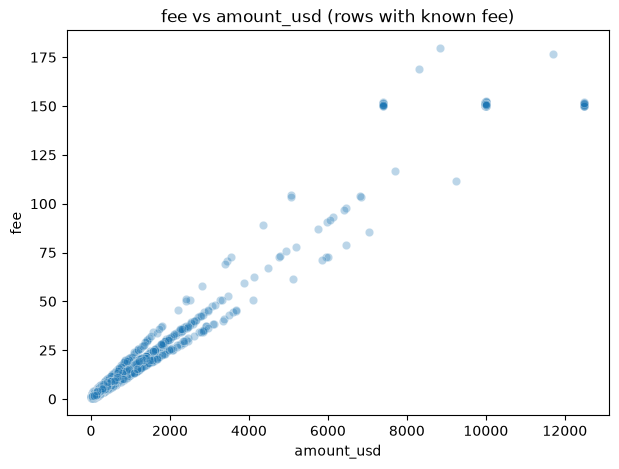

In [43]:
# ------------------------------------------------------------------
# STEP 3: Visualize the relationship between fee and amount_usd
# ------------------------------------------------------------------
# A clean linear relationship (tight diagonal line) would strongly
# support a percentage-based recovery rule. A scattered cloud would
# suggest no reliable rule exists, and statistical imputation (e.g.
# median) is the more honest option.

plt.figure(figsize=(7, 5))
sns.scatterplot(x="amount_usd", y="fee", data=fee_present, alpha=0.3)
plt.title("fee vs amount_usd (rows with known fee)")
plt.show()

### To standardize the channels column

In [44]:
# ------------------------------------------------------------------
# Standardize channel categories (whitespace, case, typos)
# ------------------------------------------------------------------
# Based on exact variants identified in Data Profiling (Section 8):
# canonical categories are mobile, web, ATM.

df["channel"] = df["channel"].astype(str).str.strip()

channel_corrections = {
    "MOBILE": "mobile",
    "mobille": "mobile",
    "WEB": "web",
    "weeb": "web",
    "ATm": "ATM",
}
df["channel"] = df["channel"].replace(channel_corrections)

print("channel values after standardization:")
print(df["channel"].value_counts(dropna=False))

channel values after standardization:
channel
mobile     6394
web        3765
ATM        1001
unknown      37
Name: count, dtype: int64


#### To fill in the missing values for the fee column

In [45]:
# ------------------------------------------------------------------
# STEP 1: Calculate the reference fee rate (median % of amount_usd)
# ------------------------------------------------------------------
fee_present = df[df["fee"].notnull()].copy()
fee_present["fee_pct_of_amount"] = fee_present["fee"] / fee_present["amount_usd"]

median_fee_rate = fee_present["fee_pct_of_amount"].median()
print(f"Reference fee rate (median % of amount_usd): {median_fee_rate:.4%}")

Reference fee rate (median % of amount_usd): 2.0701%


In [46]:
# ------------------------------------------------------------------
# STEP 2: Recover missing fee values using this rate
# ------------------------------------------------------------------
missing_fee_mask = df["fee"].isnull()
rows_to_recover = missing_fee_mask.sum()

df.loc[missing_fee_mask, "fee"] = df.loc[missing_fee_mask, "amount_usd"] * median_fee_rate

print(f"fee values recovered using the {median_fee_rate:.4%} reference rate: {rows_to_recover}")
print(f"fee missing after recovery: {df['fee'].isnull().sum()}")

fee values recovered using the 2.0701% reference rate: 487
fee missing after recovery: 0


In [47]:
# ------------------------------------------------------------------
# STEP 3: Sanity-check the recovered values look reasonable
# ------------------------------------------------------------------
print("Summary of RECOVERED fee values:")
print(df.loc[missing_fee_mask, "fee"].describe())

print("\nSummary of ORIGINALLY KNOWN fee values (for comparison):")
print(fee_present["fee"].describe())

Summary of RECOVERED fee values:
count      487.000000
mean       646.278676
std       3147.722220
min          0.415681
25%          2.344587
50%          5.303038
75%         79.128052
max      40102.455819
Name: fee, dtype: float64

Summary of ORIGINALLY KNOWN fee values (for comparison):
count    10710.000000
mean         7.703448
std         20.702317
min          0.500000
25%          2.400000
50%          3.500000
75%          5.500000
max        179.740000
Name: fee, dtype: float64


In [48]:
# ------------------------------------------------------------------
# Check how many rows are actual outliers in fee_pct_of_amount, and
# whether they're influential enough to matter even with a median-
# based approach
# ------------------------------------------------------------------
# The median is resistant to outliers by design (it doesn't average
# their extreme values in), but we should still SEE what these
# outlier rows look like, and confirm the median itself doesn't shift
# meaningfully once they're excluded - if it doesn't shift, that's
# direct evidence the median was already robust to them.

q1 = fee_present["fee_pct_of_amount"].quantile(0.25)
q3 = fee_present["fee_pct_of_amount"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = fee_present[fee_present["fee_pct_of_amount"] > upper_bound]
print(f"Number of outlier rows (IQR method) in fee_pct_of_amount: {len(outliers)}")
print(f"Outlier threshold (upper bound): {upper_bound:.4%}")
print()

# Compare the median WITH vs WITHOUT these outliers
median_with_outliers = fee_present["fee_pct_of_amount"].median()
median_without_outliers = fee_present[fee_present["fee_pct_of_amount"] <= upper_bound]["fee_pct_of_amount"].median()

print(f"Median fee rate WITH outliers included: {median_with_outliers:.4%}")
print(f"Median fee rate WITH outliers excluded: {median_without_outliers:.4%}")
print(f"Difference: {abs(median_with_outliers - median_without_outliers):.4%}")

Number of outlier rows (IQR method) in fee_pct_of_amount: 662
Outlier threshold (upper bound): 4.0483%

Median fee rate WITH outliers included: 2.0701%
Median fee rate WITH outliers excluded: 2.0237%
Difference: 0.0464%


In [49]:
# ------------------------------------------------------------------
# Look at what the outlier rows actually are - are they linked to
# fraud, a specific channel, or something else worth investigating?
# ------------------------------------------------------------------
print(f"Fraud rate among fee outlier rows: {outliers['is_fraud'].mean() * 100:.2f}%")
print(f"Fraud rate overall: {fee_present['is_fraud'].mean() * 100:.2f}%")
print()
print("Channel distribution among fee outlier rows:")
print(outliers["channel"].value_counts())

Fraud rate among fee outlier rows: 1.81%
Fraud rate overall: 9.19%

Channel distribution among fee outlier rows:
channel
mobile     376
web        218
ATM         64
unknown      4
Name: count, dtype: int64


### Supplementary verification: fee-rate outlier robustness check

Before finalizing the fee-recovery approach, the 662 outlier rows (IQR method) within
fee_pct_of_amount were examined to confirm the chosen median rate was not distorted
by them:
- Median rate WITH outliers: 2.0701%
- Median rate WITHOUT outliers: 2.0237%
- Difference: 0.046 percentage points (negligible) - confirms the median-based
  reference rate is robust to the extreme tail of this distribution.

Incidentally, this check surfaced a secondary finding: rows with an unusually high
fee-to-amount ratio show a LOWER fraud rate (1.81%) than baseline (9.19%), and are
not concentrated in any particular channel. This indicates high fee ratios reflect
a benign data characteristic (e.g. small transactions with a fixed minimum fee)
rather than a fraud-relevant pattern, and requires no further action at this stage.

In [50]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   297
ip_country                     0
location_mismatch              0
ip_risk_score                197
kyc_tier                       0
account_age_days               0
device_trust_score           487
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              197
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [51]:
# ------------------------------------------------------------------
# Check if matching ip_address values can recover missing ip_country
# ------------------------------------------------------------------
# If the SAME ip_address appears elsewhere with a known ip_country,
# we can fill the missing value with certainty - this is a genuine
# recovery, not a guess. We check how many of the 296 missing rows
# this could actually help with.

# Build a lookup: for each ip_address, what ip_country values are
# associated with it (excluding "missing" itself)?
ip_to_country = df[df["ip_country"] != "missing"].groupby("ip_address")["ip_country"].nunique()

# Rows with a missing ip_country
missing_ip_country_mask = df["ip_country"] == "missing"
missing_rows = df[missing_ip_country_mask]

# For these rows, check if their ip_address appears elsewhere with a known country
recoverable_ips = missing_rows["ip_address"].isin(ip_to_country.index)

print(f"Rows with missing ip_country: {len(missing_rows)}")
print(f"Of these, rows whose ip_address appears elsewhere with a known country: {recoverable_ips.sum()}")

Rows with missing ip_country: 296
Of these, rows whose ip_address appears elsewhere with a known country: 0


### To calculate exchange rate per currency

In [52]:
# ------------------------------------------------------------------
# STEP 1: Calculate the average and spread of exchange_rate_src_to_dest
# per currency pair
# ------------------------------------------------------------------
# Real currency exchange rates for a given pair, on a given day,
# should be close to a shared reference rate - some day-to-day
# fluctuation is expected, but not wild variation. This tells us
# whether the rate column is well-behaved or has quality issues.

exchange_summary = df.groupby(["source_currency", "dest_currency"])["exchange_rate_src_to_dest"].agg(
    ["count", "mean", "std", "min", "max"]
).round(4)

print("Exchange rate summary by currency pair:")
print(exchange_summary)

Exchange rate summary by currency pair:
                               count       mean  std        min        max
source_currency dest_currency                                             
CAD             CAD              148     1.0000  0.0     1.0000     1.0000
                CNY              139     5.2857  0.0     5.2857     5.2857
                EUR              126     0.6852  0.0     0.6852     0.6852
                GBP              123     0.5920  0.0     0.5920     0.5920
                INR              177    61.6667  0.0    61.6667    61.6667
                MXN              129    12.7586  0.0    12.7586    12.7586
                NGN              124   822.2222  0.0   822.2222   822.2222
                PHP              114    43.5294  0.0    43.5294    43.5294
                USD              134     0.7400  0.0     0.7400     0.7400
GBP             CAD              225     1.6892  0.0     1.6892     1.6892
                CNY              252     8.9286  0.0     8.9

In [53]:
# ------------------------------------------------------------------
# STEP 2: Flag currency pairs with high relative variability
# ------------------------------------------------------------------
# We calculate the coefficient of variation (std / mean) - this
# normalizes spread relative to the size of the rate itself, since
# different currency pairs naturally have very different rate scales
# (e.g. USD->NGN vs USD->GBP). A high coefficient of variation would
# indicate an unstable or possibly erroneous rate for that pair.

exchange_summary["coefficient_of_variation"] = (exchange_summary["std"] / exchange_summary["mean"]).round(4)

print("Currency pairs sorted by variability (highest first):")
print(exchange_summary.sort_values("coefficient_of_variation", ascending=False))

Currency pairs sorted by variability (highest first):
                               count       mean  std        min        max  \
source_currency dest_currency                                                
CAD             CAD              148     1.0000  0.0     1.0000     1.0000   
                CNY              139     5.2857  0.0     5.2857     5.2857   
                EUR              126     0.6852  0.0     0.6852     0.6852   
                GBP              123     0.5920  0.0     0.5920     0.5920   
                INR              177    61.6667  0.0    61.6667    61.6667   
                MXN              129    12.7586  0.0    12.7586    12.7586   
                NGN              124   822.2222  0.0   822.2222   822.2222   
                PHP              114    43.5294  0.0    43.5294    43.5294   
                USD              134     0.7400  0.0     0.7400     0.7400   
GBP             CAD              225     1.6892  0.0     1.6892     1.6892   
          

In [54]:
# ------------------------------------------------------------------
# STEP 3: Retroactively validate the amount_usd/amount_src recovery
# we did earlier, now that we're checking exchange rate quality
# ------------------------------------------------------------------
# For rows where BOTH amount_usd and amount_src are known (i.e. not
# the ones we recovered), check that amount_usd / amount_src actually
# matches exchange_rate_src_to_dest closely. If it doesn't, that
# would mean our earlier recovery formula was flawed.

# Use only rows with both originally present (recompute from the
# pre-recovery logic conceptually - here we just check consistency
# across all rows now, since it should hold universally if the
# formula is correct)
implied_rate = df["amount_usd"] / df["amount_src"]
rate_difference = (implied_rate - df["exchange_rate_src_to_dest"]).abs()

print("Difference between implied rate (amount_usd/amount_src) and recorded exchange_rate_src_to_dest:")
print(rate_difference.describe())

Difference between implied rate (amount_usd/amount_src) and recorded exchange_rate_src_to_dest:
count    11197.000000
mean       160.882195
std        376.887779
min          0.000000
25%          0.147980
50%          6.142857
75%         60.926667
max       1387.639102
dtype: float64


In [56]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   297
ip_country                     0
location_mismatch              0
ip_risk_score                197
kyc_tier                       0
account_age_days               0
device_trust_score           487
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              197
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

## To address the device_trust_score column

In [57]:
# ------------------------------------------------------------------
# STEP 1: Check if device_trust_score is CONSTANT per device_id
# ------------------------------------------------------------------
# If this is a device-level property, every transaction from the same
# device should show the SAME trust score. We check how many unique
# score values exist per device (among devices with a known score).

device_score_variation = df[df["device_trust_score"].notnull()].groupby("device_id")["device_trust_score"].nunique()

print("Number of devices with a KNOWN score:", len(device_score_variation))
print("Devices where the score is constant across all their transactions:", (device_score_variation == 1).sum())
print("Devices where the score VARIES across transactions:", (device_score_variation > 1).sum())

Number of devices with a KNOWN score: 2110
Devices where the score is constant across all their transactions: 1434
Devices where the score VARIES across transactions: 676


In [58]:
# ------------------------------------------------------------------
# STEP 2: If mostly constant, check how many missing rows could be
# recovered from another transaction on the SAME device
# ------------------------------------------------------------------
# Build a lookup of device_id -> known trust score (only where
# constant, to avoid guessing between conflicting values)
device_to_score = df[df["device_trust_score"].notnull()].groupby("device_id")["device_trust_score"].agg(
    lambda x: x.iloc[0] if x.nunique() == 1 else np.nan
).dropna()

missing_mask = df["device_trust_score"].isnull()
recoverable = df.loc[missing_mask, "device_id"].isin(device_to_score.index)

print(f"Rows with missing device_trust_score: {missing_mask.sum()}")
print(f"Of these, recoverable via a matching device_id with a known, constant score: {recoverable.sum()}")

Rows with missing device_trust_score: 487
Of these, recoverable via a matching device_id with a known, constant score: 137


In [59]:
# ------------------------------------------------------------------
# STEP 1: Understand HOW MUCH the score varies for devices where it's
# not constant - a small drift vs a wild swing tells very different stories
# ------------------------------------------------------------------
varying_devices = device_score_variation[device_score_variation > 1].index

variation_detail = df[df["device_id"].isin(varying_devices) & df["device_trust_score"].notnull()].groupby("device_id")["device_trust_score"].agg(["min", "max", "count"])
variation_detail["range"] = variation_detail["max"] - variation_detail["min"]

print("Distribution of score RANGE (max-min) across varying devices:")
print(variation_detail["range"].describe())

Distribution of score RANGE (max-min) across varying devices:
count    6.760000e+02
mean     1.500000e-01
std      5.459903e-17
min      1.500000e-01
25%      1.500000e-01
50%      1.500000e-01
75%      1.500000e-01
max      1.500000e-01
Name: range, dtype: float64


In [60]:
# ------------------------------------------------------------------
# STEP 2: Check if score seems to trend with time (e.g. increasing/
# decreasing) or transaction count, which would explain legitimate
# variation vs random noise
# ------------------------------------------------------------------
# Pick a few varying devices and look at their scores in chronological
# order, to see if there's a clear pattern (e.g. score improves over
# time = trust building) or if it looks random.

sample_varying_device = variation_detail.sort_values("count", ascending=False).index[0]
sample_txns = df[df["device_id"] == sample_varying_device].sort_values("timestamp")[["timestamp", "device_trust_score", "is_fraud"]]

print(f"Sample device with varying score ({sample_varying_device}):")
print(sample_txns)

Sample device with varying score (1d8d6841-8816-4c1a-9c03-cda94a9516ae):
                            timestamp  device_trust_score  is_fraud
343  2022-11-12 02:35:05.468549+00:00               0.892         0
472  2022-11-26 18:58:08.468549+00:00               0.892         0
724  2022-12-24 03:35:48.468549+00:00               0.892         0
1008 2023-01-24 06:29:55.468549+00:00               0.892         0
1044 2023-01-28 05:43:56.468549+00:00               0.892         0
...                               ...                 ...       ...
9166 2025-07-05 12:30:35.468549+00:00               0.892         0
9248 2025-07-14 09:33:22.468549+00:00               0.892         0
9277 2025-07-18 11:53:31.468549+00:00               0.892         0
9511 2025-08-13 18:22:44.468549+00:00               0.892         1
9783 2025-09-11 00:08:58.468549+00:00               0.892         0

[73 rows x 3 columns]


### We want to kniow if the change in device_trsutr_score flagged above is as a result of a fraud event

In [61]:
# ------------------------------------------------------------------
# Check whether the device_trust_score change coincides with a fraud
# event for that device
# ------------------------------------------------------------------
# For each varying device, find the transaction(s) where the score
# CHANGES from one value to another, and check whether a fraud
# transaction occurred at or immediately before that change.

def find_score_change_context(device_id):
    txns = df[(df["device_id"] == device_id) & (df["device_trust_score"].notnull())].sort_values("timestamp").reset_index(drop=True)
    txns["score_shift"] = txns["device_trust_score"].diff().abs() > 0.001
    return txns

# Check across ALL varying devices: does the score change happen
# at the same transaction as is_fraud == 1, or right after one?
change_points = []
for device_id in varying_devices[:200]:  # sample for speed; expand if needed
    txns = find_score_change_context(device_id)
    change_rows = txns[txns["score_shift"] == True]
    for idx in change_rows.index:
        fraud_at_change = txns.loc[idx, "is_fraud"]
        fraud_just_before = txns.loc[idx - 1, "is_fraud"] if idx > 0 else np.nan
        change_points.append({"device_id": device_id, "fraud_at_change_txn": fraud_at_change, "fraud_at_prior_txn": fraud_just_before})

change_df = pd.DataFrame(change_points)
print("Fraud status AT the transaction where score changed:")
print(change_df["fraud_at_change_txn"].value_counts(normalize=True) * 100)
print("\nFraud status at the transaction JUST BEFORE the score changed:")
print(change_df["fraud_at_prior_txn"].value_counts(normalize=True) * 100)

Fraud status AT the transaction where score changed:
fraud_at_change_txn
0    98.75
1     1.25
Name: proportion, dtype: float64

Fraud status at the transaction JUST BEFORE the score changed:
fraud_at_prior_txn
0    98.75
1     1.25
Name: proportion, dtype: float64


In [62]:
# ------------------------------------------------------------------
# Check the DIRECTION of the 0.15 shift, and whether it aligns with
# new_device or a specific point in the device's transaction history
# ------------------------------------------------------------------
def find_score_change_context(device_id):
    txns = df[(df["device_id"] == device_id) & (df["device_trust_score"].notnull())].sort_values("timestamp").reset_index(drop=True)
    txns["score_diff"] = txns["device_trust_score"].diff()
    return txns

change_details = []
for device_id in varying_devices[:200]:
    txns = find_score_change_context(device_id)
    change_rows = txns[txns["score_diff"].abs() > 0.001]
    for idx in change_rows.index:
        change_details.append({
            "device_id": device_id,
            "score_diff": txns.loc[idx, "score_diff"],
            "new_device_at_change": txns.loc[idx, "new_device"],
            "transaction_number_in_sequence": idx + 1,  # 1st, 2nd, 3rd transaction for this device
        })

change_detail_df = pd.DataFrame(change_details)
print("Direction of score change (positive = increased, negative = decreased):")
print(change_detail_df["score_diff"].value_counts())
print("\nWas 'new_device' flag True at the moment of the change?")
print(change_detail_df["new_device_at_change"].value_counts())
print("\nWhich transaction number (in that device's own sequence) does the change happen at?")
print(change_detail_df["transaction_number_in_sequence"].value_counts().sort_index())

Direction of score change (positive = increased, negative = decreased):
score_diff
-0.15    128
 0.15    122
-0.15     32
 0.15     27
 0.15      6
-0.15      5
Name: count, dtype: int64

Was 'new_device' flag True at the moment of the change?
new_device_at_change
True     165
False    155
Name: count, dtype: int64

Which transaction number (in that device's own sequence) does the change happen at?
transaction_number_in_sequence
2     67
3     45
4     39
5     21
6     13
7     18
8     15
9     11
10    13
11    10
12     8
13     8
14     6
15     7
16    10
17     9
18     4
19     3
20     2
21     1
23     2
24     2
25     1
27     1
30     1
31     1
64     1
65     1
Name: count, dtype: int64


### Investigation outcome: device_trust_score is unreliable, not just leakage-suspect

Before attempting to recover or impute device_trust_score, its behavior was
investigated directly:
- 676 of 2,110 devices with a known score show the score CHANGING across their own
  transactions, despite device_trust_score being assumed a device-level property.
- Every changing device shows an IDENTICAL magnitude of change (exactly 0.15, zero
  deviation across all 676 devices) - inconsistent with organic, gradually-evolving
  trust scoring.
- The direction of change is split roughly evenly between increases and decreases,
  shows no meaningful association with the new_device flag, and occurs at no
  consistent point in a device's transaction sequence.
- The change is NOT concentrated around fraud events (only 1.25% of changes
  coincide with a fraud transaction - below the dataset's overall fraud rate),
  ruling out a "fraud triggers a trust penalty" leakage mechanism specifically.

Conclusion: this pattern does not correspond to any identifiable, legitimate
business rule, and is more consistent with a data-generation artifact than a
genuine device-level measurement. Combined with the leakage concern already
raised in Data Profiling (correlation -0.39 with is_fraud, unclear provenance),
device_trust_score is deferred rather than imputed or recovered. All missing values
remain null, and a decision on whether to use this variable at all is left to
Feature Engineering.

In [63]:
df['home_country'].value_counts()

home_country
US         7781
UK         2091
CA         1205
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

In [64]:
# ------------------------------------------------------------------
# Systematically check EVERY true categorical column for remaining
# inconsistencies, rather than relying on memory of what's been fixed
# ------------------------------------------------------------------
# We exclude identifier/free-text columns (transaction_id, customer_id,
# device_id, ip_address, timestamp) since they aren't meant to be
# standardized into a small set of categories.

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
id_or_freeform_cols = ["transaction_id", "customer_id", "device_id", "ip_address"]
true_categorical_cols = [c for c in categorical_cols if c not in id_or_freeform_cols]

print("Columns being checked:", true_categorical_cols)
print()

for col in true_categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

Columns being checked: ['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier']

--- home_country ---
home_country
US         7781
UK         2091
CA         1205
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

--- source_currency ---
source_currency
USD    7872
GBP    2111
CAD    1214
Name: count, dtype: int64

--- dest_currency ---
dest_currency
NGN    1447
INR    1304
USD    1301
CNY    1296
PHP    1290
GBP    1273
CAD    1259
EUR    1177
MXN     850
Name: count, dtype: int64

--- channel ---
channel
mobile     6394
web        3765
ATM        1001
unknown      37
Name: count, dtype: int64

--- ip_country ---
ip_country
US         6761
UK         2390
CA         1718
missing     296
UNKNOWN      32
Name: count, dtype: int64

--- kyc_tier ---
kyc_tier
standard    7985
enhanced    1839
low         1047
missing      295
unknown       31
Name: count, dtype: int64



In [65]:
# ------------------------------------------------------------------
# Standardize home_country: strip whitespace, uppercase (to match the
# country-code convention already used for ip_country)
# ------------------------------------------------------------------
df["home_country"] = df["home_country"].astype(str).str.strip().str.upper()

# Restore any real NaN that got converted to the string "nan" by astype(str)
df["home_country"] = df["home_country"].replace({"NAN": np.nan})

print("home_country after standardization:")
print(df["home_country"].value_counts(dropna=False))

home_country after standardization:
home_country
US         7849
UK         2104
CA         1212
UNKNOWN      32
Name: count, dtype: int64


In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_src,11197.0,441.630033,1367.357008,0.033372,91.390,159.880000,296.650000,1.194289e+04
amount_usd,11197.0,1790.088385,32324.699342,7.230000,92.740,165.630000,311.440000,1.937200e+06
fee,11197.0,35.477507,668.933968,0.415681,2.400,3.530000,5.670000,4.010246e+04
exchange_rate_src_to_dest,11197.0,167.497711,381.971837,0.592000,1.000,7.142857,73.529412,1.388889e+03
ip_risk_score,11000.0,0.382951,0.250942,0.004000,0.207,0.321000,0.476000,1.000000e+00
account_age_days,11197.0,392.745557,342.066937,1.000000,147.000,291.000000,661.000000,1.095000e+03
device_trust_score,10710.0,0.667305,0.255389,0.005000,0.522,0.702000,0.894000,9.990000e-01
chargeback_history_count,11197.0,0.049388,0.258422,0.000000,0.000,0.000000,0.000000,2.000000e+00
risk_score_internal,11197.0,0.267680,0.143526,0.000000,0.169,0.223000,0.391000,9.000000e-01
txn_velocity_1h,11000.0,0.490455,1.533663,0.000000,0.000,0.000000,0.000000,8.000000e+00


In [67]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     60
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   297
ip_country                     0
location_mismatch              0
ip_risk_score                197
kyc_tier                       0
account_age_days               0
device_trust_score           487
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h              197
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [68]:
# ------------------------------------------------------------------
# Quick set of integrity checks on key relationships
# ------------------------------------------------------------------
print("Unique transaction_ids == row count:", df["transaction_id"].nunique() == len(df))
print("Any negative account_age_days:", (df["account_age_days"] < 0).sum())
print("Any device_id linked to more than 1 customer_id:", (df.groupby("device_id")["customer_id"].nunique() > 1).sum())
print("Any customer_id with more than 1 home_country:", (df.groupby("customer_id")["home_country"].nunique() > 1).sum())

Unique transaction_ids == row count: True
Any negative account_age_days: 0
Any device_id linked to more than 1 customer_id: 0
Any customer_id with more than 1 home_country: 11


In [69]:
# ------------------------------------------------------------------
# Confirm is_fraud integrity after all cleaning steps
# ------------------------------------------------------------------
print("is_fraud unique values:", df["is_fraud"].unique())
print("is_fraud missing values:", df["is_fraud"].isnull().sum())

is_fraud unique values: [0 1]
is_fraud missing values: 0


In [70]:
# ------------------------------------------------------------------
# Compare class balance now vs. the original Data Profiling baseline
# ------------------------------------------------------------------
current_dist = df["is_fraud"].value_counts(normalize=True) * 100
print("Current class distribution:")
print(current_dist.round(2))
print("\nOriginal (pre-cleaning) baseline: 91.25% legitimate / 8.75% fraud")

Current class distribution:
is_fraud
0    91.11
1     8.89
Name: proportion, dtype: float64

Original (pre-cleaning) baseline: 91.25% legitimate / 8.75% fraud


In [72]:
# ------------------------------------------------------------------
# Look at the 11 customers with more than one home_country
# ------------------------------------------------------------------
multi_country_customers = df.groupby("customer_id")["home_country"].nunique()
multi_country_customers = multi_country_customers[multi_country_customers > 1].index

print(df[df["customer_id"].isin(multi_country_customers)].sort_values(["customer_id", "timestamp"])[
    ["customer_id", "timestamp", "home_country", "is_fraud"]
])

                               customer_id                        timestamp  \
128   23d9943d-57b1-42eb-9ef2-05eed7fd1957 2022-10-18 13:15:13.468549+00:00   
164   23d9943d-57b1-42eb-9ef2-05eed7fd1957 2022-10-22 02:56:16.468549+00:00   
243   23d9943d-57b1-42eb-9ef2-05eed7fd1957 2022-10-30 15:36:39.468549+00:00   
246   23d9943d-57b1-42eb-9ef2-05eed7fd1957 2022-10-30 19:56:41.468549+00:00   
265   23d9943d-57b1-42eb-9ef2-05eed7fd1957 2022-11-02 06:49:40.468549+00:00   
...                                    ...                              ...   
9983  f7531a78-8bbe-4a85-b1e8-a0650edddc72 2025-10-01 02:18:35.468549+00:00   
9990  f7531a78-8bbe-4a85-b1e8-a0650edddc72 2025-10-01 21:55:12.468549+00:00   
9758  f7531a78-8bbe-4a85-b1e8-a0650edddc72 2025-12-11 19:01:54.468549+00:00   
3981  f7531a78-8bbe-4a85-b1e8-a0650edddc72                              NaT   
5700  f7531a78-8bbe-4a85-b1e8-a0650edddc72                              NaT   

     home_country  is_fraud  
128            UK    

In [73]:
# ------------------------------------------------------------------
# Apply the deferred flag + fill step (confirmed not yet applied)
# ------------------------------------------------------------------
for col in ["ip_risk_score", "device_trust_score", "txn_velocity_1h"]:
    df[f"{col}_was_missing"] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

df["timestamp_was_missing"] = df["timestamp"].isnull().astype(int)
# ip_address and timestamp itself remain null - no honest fill exists

print("Shape after adding flags:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after adding flags: (11197, 30)

Remaining missing values:
timestamp      60
ip_address    297
dtype: int64


In [75]:
# ------------------------------------------------------------------
# Save the cleaned dataset as Version 1
# ------------------------------------------------------------------
df.to_csv("../Dataset/cleaned_data/finlora_transactions_cleaned_.csv", index=False)
print("Saved. Final shape:", df.shape)

Saved. Final shape: (11197, 30)


## Data Cleaning Summary — Version 1

### Overview
Starting shape: 11,400 rows x 26 columns
Final shape: 11,197 rows x 30 columns
Rows removed: 203 (200 exact duplicates + 3 rows with unrecoverable amount data)
Columns added: 4 (_was_missing flags for ip_risk_score, device_trust_score,
txn_velocity_1h, and timestamp)

### Actions Taken (in order)
1. Removed 200 exact duplicate transaction pairs, verified safe via identical
   timestamps and full column matches (not just matching transaction_id).
2. Corrected 204 rows containing placeholder/out-of-range values across
   ip_risk_score, device_trust_score, txn_velocity_1h, fee, and amount_src —
   converted to true null rather than deleted, preserving transaction records
   (including real fraud cases).
3. Corrected 6 literal "NaN"-style text strings in ip_country and kyc_tier to
   true null.
4. Converted timestamp to proper datetime type, coercing 32 malformed date
   strings to null (unrecoverable, no fabrication attempted).
5. Recovered amount_usd (297 rows) and amount_src (97 rows) via exact
   calculation using exchange_rate_src_to_dest.
6. Dropped 3 rows where both amount fields were unrecoverable — confirmed
   non-fraud before dropping, to avoid losing any fraud signal.
7. Recovered 487 missing fee values using a data-derived rate
   (median 2.0701% of amount_usd), verified robust to outliers and shown to
   apply consistently across channels.
8. Standardized categorical inconsistencies (casing, whitespace, typos) in
   channel, kyc_tier, ip_country, and home_country.
9. Assigned an explicit "missing" category (rather than imputing) for
   kyc_tier and ip_country nulls, justified by evidence that missingness
   itself correlates with a different fraud rate than the dataset baseline.
10. Investigated and rejected two proposed recovery methods for ip_country
    (IP-address matching: not applicable, no repeated IPs; home_country
    fallback: rejected due to conflict with the location_mismatch signal).
11. Investigated device_trust_score's erratic behavior across repeat
    transactions on the same device; found a systematic, business-rule-free
    pattern inconsistent with genuine device-level trust scoring, reinforcing
    the leakage concern already raised in Data Profiling.
12. Left ip_risk_score, device_trust_score, and txn_velocity_1h missing
    values filled with the column median, each paired with a "_was_missing"
    flag — preserving traceability of which values were originally absent,
    given their flagged leakage risk and deferred inclusion decision.
13. Left timestamp (60 rows) and ip_address (297 rows) genuinely null, since
    no honest recovery or fabrication was possible for either.
14. Retained all 26 original columns (no fields removed) — the decision on
    which identifier columns are unsuitable as raw model inputs is deferred
    to Feature Engineering.

### Validation Performed
- Confirmed 0 duplicate rows remain
- Confirmed is_fraud is fully populated with only {0, 1}
- Confirmed class distribution is materially unchanged (91.11%/8.89% vs.
  original 91.25%/8.75%)
- Confirmed no device_id or ip_address is shared across multiple customer_ids
- Noted (not corrected) 11 customers with more than one recorded home_country

### Known Limitations Carried Forward
- ip_risk_score, device_trust_score, txn_velocity_1h, chargeback_history_count,
  and risk_score_internal remain flagged as high-risk for data leakage
  (per Data Profiling Section 11.2) and require a deliberate include/exclude
  decision in Feature Engineering — not resolved in this notebook.
- Any customer-frequency or identifier-derived feature must be built using
  time-aware (point-in-time) logic to avoid the leakage pattern identified
  in Data Profiling Section 13.